240000


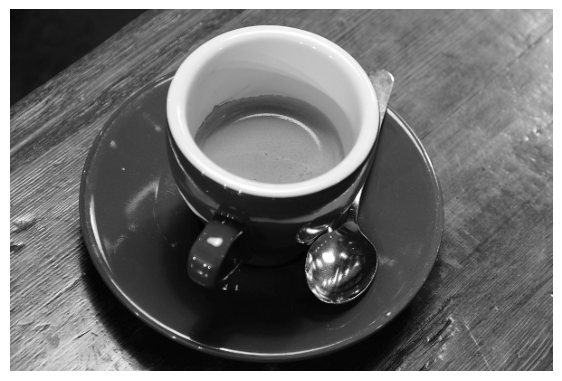

In [ ]:
import skimage as si
import skimage.color as sc
import matplotlib.pyplot as plt
import numpy as np
import scipy.signal as ss
from algorithms import Algorithms
import time

img = sc.rgb2gray( si.data.coffee() )

print( np.prod( img.shape ) )

plt.figure( figsize = ( 7, 7 ) )
plt.imshow( img, cmap = plt.cm.gray )
plt.axis( "off" )
plt.show()

In [2]:
N_kernel = 7
kernel = np.full( ( N_kernel, N_kernel ), 1 / ( N_kernel ** 2 ) )

def A( x ):
    return ss.convolve2d( x, kernel, mode = "same" )

def A_transpose( x ):
    return ss.correlate2d( x, kernel, mode = "same" )

def ATA( x ):
    return A_transpose( A( x ) )

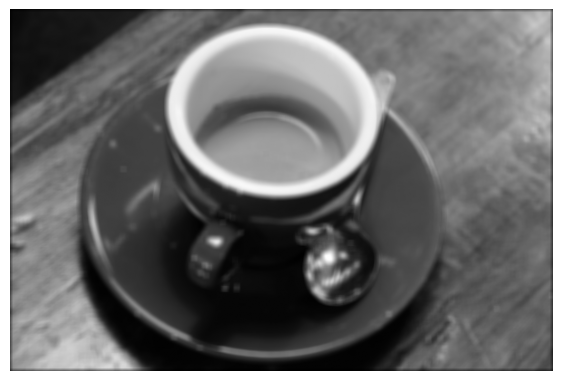

In [3]:
b = A( img )
plt.figure( figsize = ( 7, 7 ) )
plt.imshow( b, cmap = plt.cm.gray )
plt.axis( "off" )
plt.show()

Note que: $f(x) = \frac{1}{2}||Ax - b||_2^2 = \frac{1}{2} x^T (A^TA) x -2x^T(A^Tb) + b^Tb$.

No gradiente conjugado, a matriz $Q = A^TA$.


In [4]:
def f( x ):
    return 1/2 * ( (A( x ) - b) ** 2 ).sum()

def grad_f( x ):
    return A_transpose( A( x ) - b )

In [5]:
x0 = np.zeros_like( img )
x = np.zeros_like( img )
iters_mdbe = Algorithms.mdbe( f, grad_f, Q = ATA, x0 = x0, tol = 1.0e-1 )

In [6]:
iters_nesterov_fixo = Algorithms.nesterov_fixo( f, grad_f, x = x, step = 1.0e-1, tol = 1.0e-1 )

In [7]:
iters_conjugate = Algorithms.conjugate( ATA, A_transpose( b ), x0, f, tol = 1.0e-1 )


In [8]:
iters_nesterov_exato = Algorithms.nesterov_exato( f, grad_f, Q = ATA, x = x, tol = 1.0e-1 )

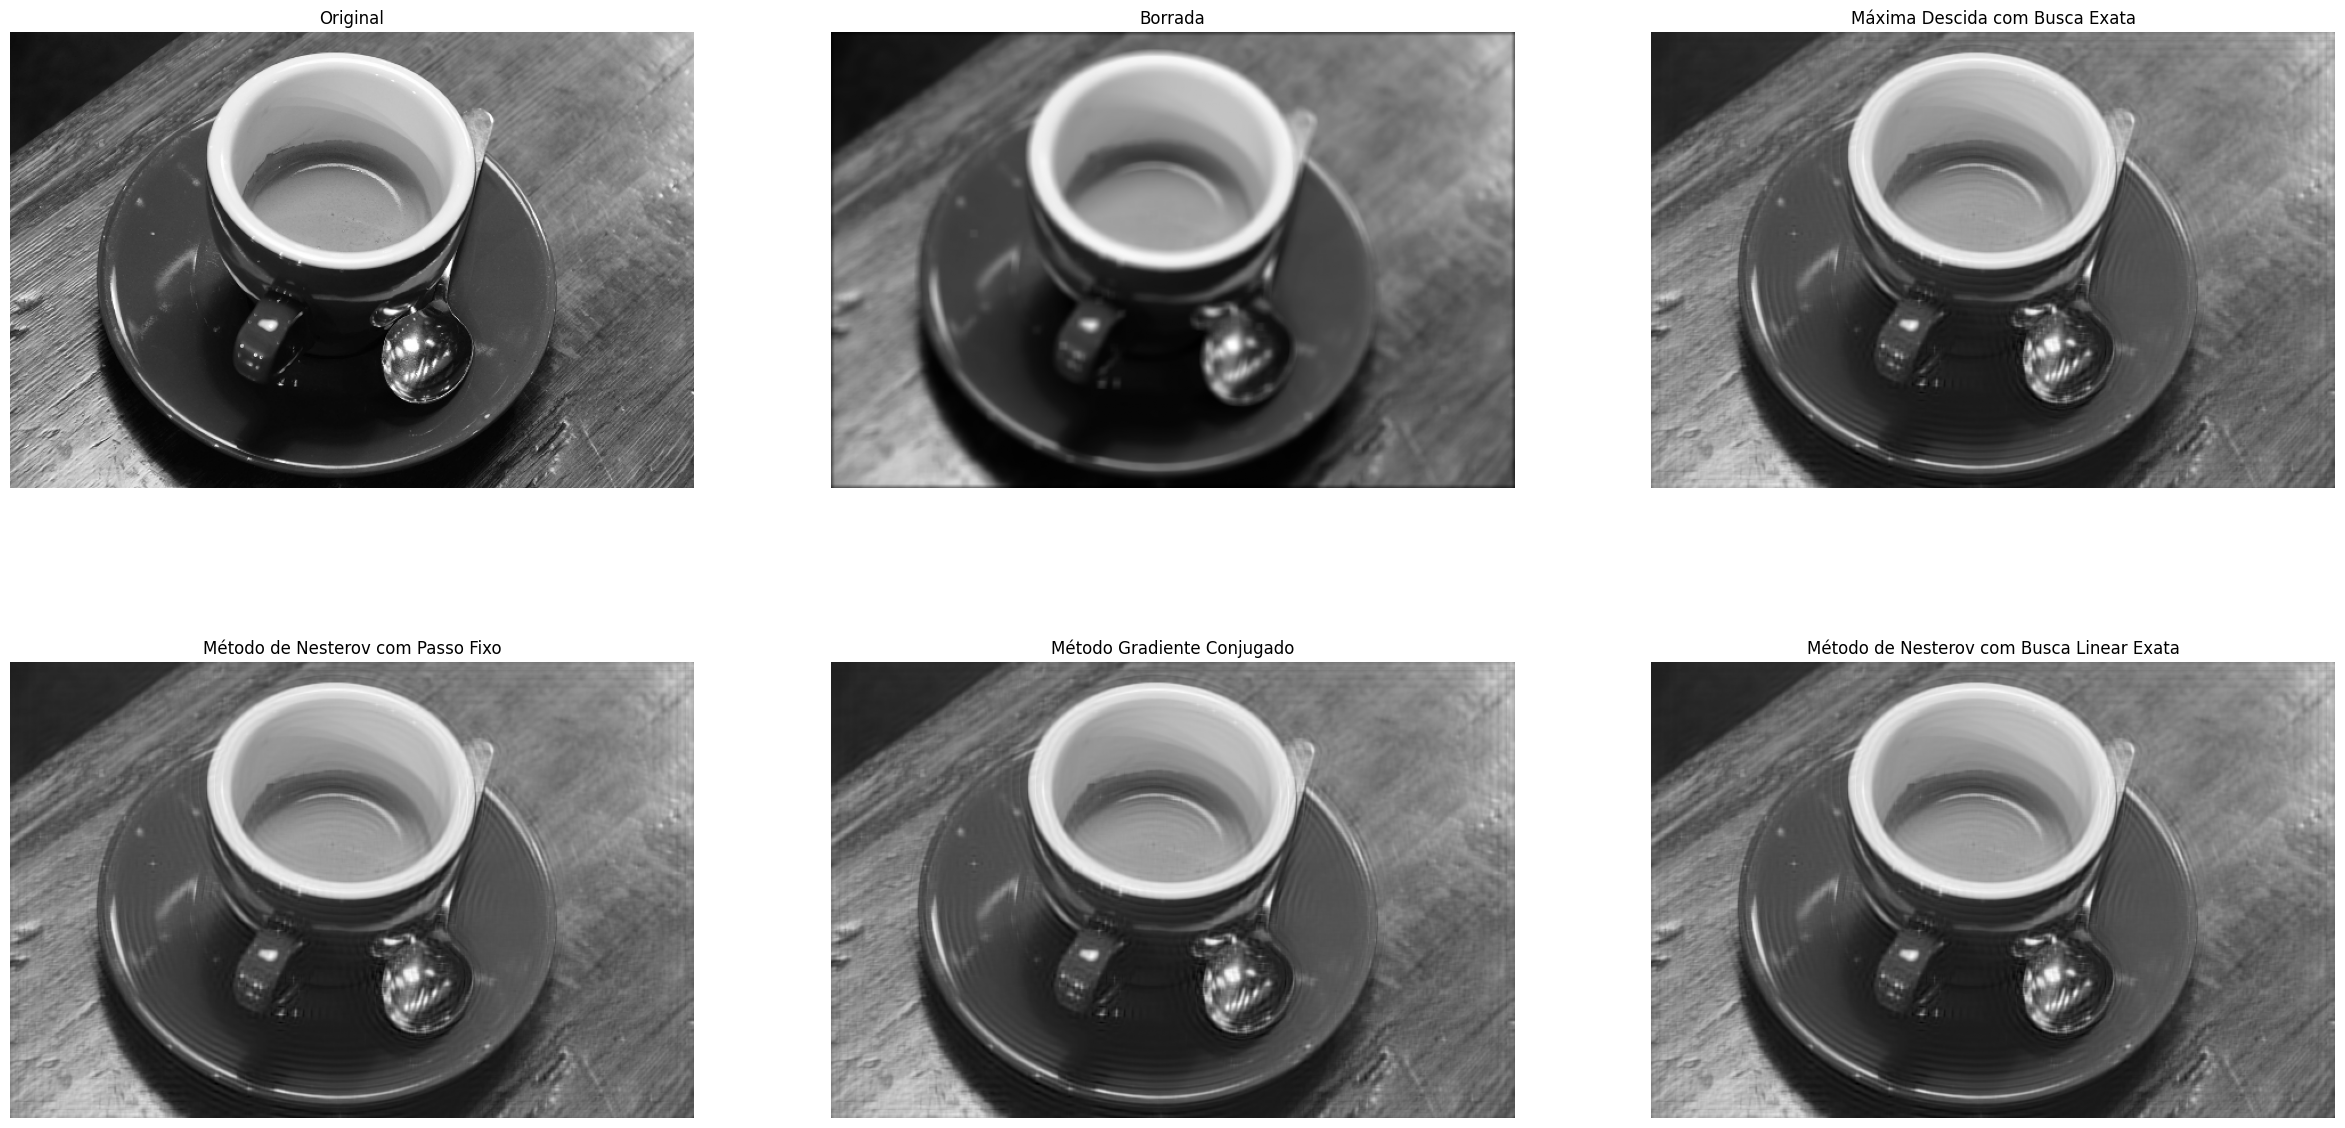

In [9]:
plt.figure( figsize = ( 30, 15 ) )

plt.subplot( 2, 3, 1 )
plt.imshow( img, cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "Original" )

plt.subplot( 2, 3, 2 )
plt.imshow( b, cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "Borrada" )

plt.subplot( 2, 3, 3 )
plt.imshow( iters_mdbe[ -1 ], cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "Máxima Descida com Busca Exata" )

plt.subplot( 2, 3, 4 )
plt.imshow( iters_nesterov_fixo[ -1 ], cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "Método de Nesterov com Passo Fixo" )

plt.subplot( 2, 3, 5 )
plt.imshow( iters_conjugate[ -1 ], cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "Método Gradiente Conjugado" )

plt.subplot( 2, 3, 6 )
plt.imshow( iters_nesterov_exato[ -1 ], cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "Método de Nesterov com Busca Linear Exata" )


plt.show()


In [10]:
print( f"O número de iterações do método da máxima descida com busca exata foi de: {len( iters_mdbe )}\n")
print( f"O número de iterações do método Nesterov com Passo Fixo foi de: {len( iters_nesterov_fixo )}\n")
print( f"O número de iterações do método Gradiente Conjugado foi de: {len( iters_conjugate )}\n")
print( f"O número de iterações do método Nesterov com Busca Linear Exata foi de: { len( iters_nesterov_exato ) }\n" )

O número de iterações do método da máxima descida com busca exata foi de: 105

O número de iterações do método Nesterov com Passo Fixo foi de: 122

O número de iterações do método Gradiente Conjugado foi de: 18

O número de iterações do método Nesterov com Busca Linear Exata foi de: 31



In [11]:
f_vals_mdbe = [ f( x ) for x in iters_mdbe ]
f_vals_nesterov_fixo = [ f( x ) for x in iters_nesterov_fixo ]
f_vals_conjugate = [ f( x ) for x in iters_conjugate ]
f_vals_nesterov_exato = [ f( x ) for x in iters_nesterov_exato ]

(np.float64(-6.050000000000001),
 np.float64(127.05),
 np.float64(0.053289208055587824),
 np.float64(43647.77062447405))

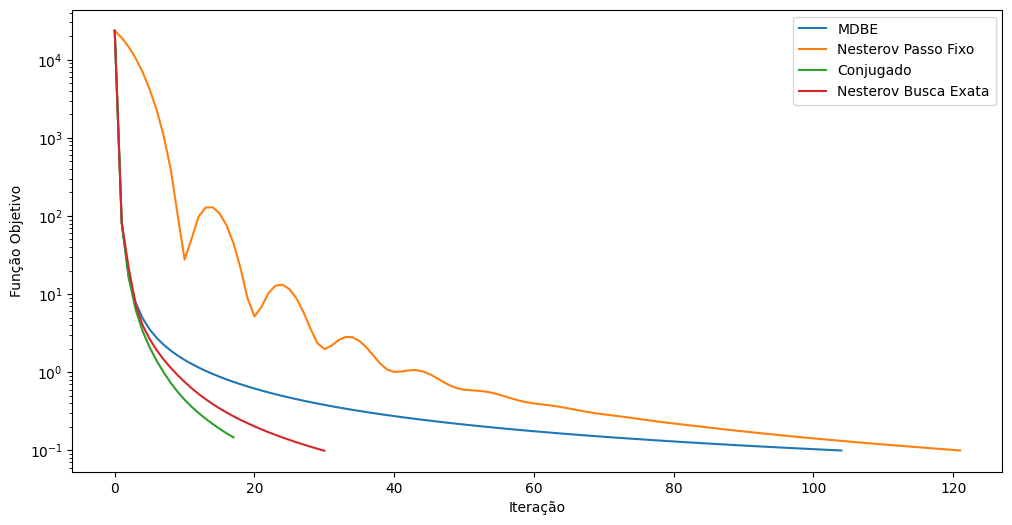

In [12]:
plt.figure( figsize = ( 12, 6 ) )
plt.semilogy( f_vals_mdbe )
plt.semilogy( f_vals_nesterov_fixo )
plt.semilogy( f_vals_conjugate )
plt.semilogy( f_vals_nesterov_exato )
plt.legend( [ "MDBE", "Nesterov Passo Fixo", "Conjugado", "Nesterov Busca Exata" ] )
plt.xlabel( "Iteração" )
plt.ylabel( "Função Objetivo" )
plt.axis( "tight" )

In [13]:
def compare_methods( methods, f, grad_f, x0, tol = 1e-4, max_iter = 10000 ):
    results = {}
    for name, method in methods.items():
        print( f"Executando método: {name}" )
        start_time = time.perf_counter()
        iters = method( f, grad_f, x0, tol = tol, max_iter = max_iter )
        end_time = time.perf_counter()

        exec_time = end_time - start_time
        values = [ f( x ) for x in iters ]

        results[ name ] = {
            "iterations": len( iters ),
            "execution_time": exec_time,
            "function_values": values
        }
        print( f"{name}: {len( iters )} iterações, {exec_time:.4f} segundos." )
    return results

In [14]:
x0 = np.zeros_like( img )
tol = 1e-2
max_iter = 1000


In [15]:
methods = {
    "MDBE": lambda f, grad_f, x0, tol, max_iter: Algorithms.mdbe( f, grad_f, Q = ATA, x0 = x0, tol = tol, max_iter = max_iter ),
    "Nesterov Passo Fixo": lambda f, grad_f, x0, tol, max_iter: Algorithms.nesterov_fixo( f, grad_f, x0, step = 1e-1, tol = tol, max_iter = max_iter ),
    "Nesterov Busca Exata": lambda f, grad_f, x0, tol, max_iter: Algorithms.nesterov_exato( f, grad_f, x = x0, Q = ATA, tol = tol, max_iter = max_iter ),
    "Gradiente Conjugado" : lambda f, grad_f, x0, tol, max_iter: Algorithms.conjugate( ATA, A_transpose( b ), x0, f, tol = tol, max_iter = max_iter )
}

results = compare_methods( methods, f, grad_f, x0, tol = tol, max_iter = max_iter )


Executando método: MDBE
MDBE: 849 iterações, 62.2922 segundos.
Executando método: Nesterov Passo Fixo
Nesterov Passo Fixo: 352 iterações, 16.2033 segundos.
Executando método: Nesterov Busca Exata
Nesterov Busca Exata: 93 iterações, 7.1019 segundos.
Executando método: Gradiente Conjugado
Gradiente Conjugado: 59 iterações, 4.4015 segundos.


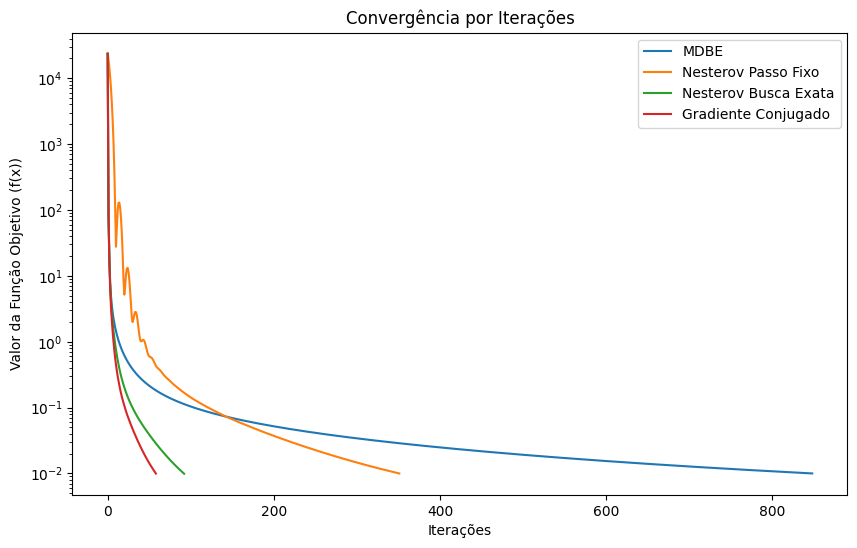

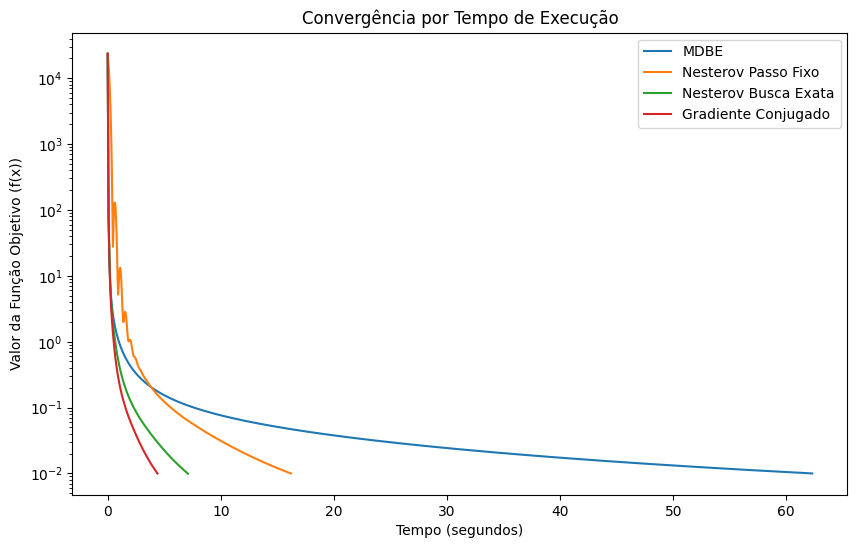

In [16]:
plt.figure( figsize = ( 10, 6 ) )
for name, res in results.items():
    plt.plot( res[ "function_values" ], label = name )
plt.xlabel( "Iterações" )
plt.ylabel( "Valor da Função Objetivo (f(x))" )
plt.yscale( "log" )
plt.legend()
plt.title( "Convergência por Iterações" )
plt.show()

plt.figure( figsize = ( 10, 6 ) )
for name, res in results.items():
    times = np.linspace( 0, res[ "execution_time" ], len( res[ "function_values" ] ) )
    plt.plot( times, res[ "function_values" ], label = name )
plt.xlabel( "Tempo (segundos)" )
plt.ylabel( "Valor da Função Objetivo (f(x))" )
plt.yscale( "log" )
plt.legend()
plt.title( "Convergência por Tempo de Execução" )
plt.show()
